# Приоритизация обращений

Обучение модели на готовых табличных признаках из `train.csv` / `test.csv` и создание `submission_ensemble_70.csv`. Также используем дополнительно `events.csv` для улучшения решения.

### Выполненные шаги

##### Шаг 0: Загрузка и запуск quickstart.ipynb
- Загружены библиотеки и данные
- Запущен baseline (Logistic Regression)
- Baseline AP = 0.48506

##### Шаг 1: Изучение данных (EDA)
- Размеры: train 13694 × 119, test 4306 × 118, events 254705 × 7
- Доля target = 20.75% (дисбаланс умеренный)
- 7 категориальных признаков: lead_source, call_center, region, car_segment, lead_channel, user_tenure_bucket, price_bucket
- 108 числовых признаков (агрегации за окна 1d, 3d, 7d, 14d, 30d, 90d)
- 5 типов событий: item_view, search, favorite, chat_open, call_click
- Пропуски: 97 из 119 колонок
- Распределение по датам: train 07.04–22.04 (16 дней), test 23.04–27.04 (5 дней) — тест позже train, используется временная валидация

##### Шаг 2: Флаги пропусков (is_missing)
- Добавлено 97 флагов пропусков для колонок с NaN
- Каждый флаг показывает, было ли пропущено значение в соответствующей колонке
- Итог: train (13694, 216), test (4306, 215)

##### Шаг 3: Построение признаков из events.csv
- Фильтрация событий ДО назначения (защита от читинга): 91.8% событий доступны
- Создано 8 новых признаков:
  - total_events — общее количество событий до назначения
  - unique_event_types — количество уникальных типов событий
  - event_span_days — разброс событий во времени
  - nw_item_view, nw_search, nw_favorite, nw_chat_open, nw_call_click — количество каждого типа событий
- Итог: train (13694, 224), test (4306, 223)

##### Шаг 4: Обучение базового LightGBM
- Модель: LightGBM с early stopping (50 раундов)
- Валидация: временная (70% дат — обучение, 30% — валидация)
- Категориальные признаки: преобразованы в тип category (LightGBM обрабатывает автоматически)
- Результат: AP = 0.53832 (улучшение на +11.0% относительно baseline)

##### Шаг 5: Ансамбль моделей
- Для повышения стабильности и качества прогнозов обучен ансамбль из 3 моделей LightGBM с разными seed (42, 123, 456)
- Предсказания моделей усредняются
- Результат на валидации: AP = 0.54749

##### Шаг 6: Анализ важности признаков
- Топ-3 важных признака: seller_page_views_30d, seller_page_views_14d, user_age_days
- Признаки из events попали в топ-30, подтверждая пользу feature engineering

##### Шаг 7: Финальный результат
- Лучший результат на тестовой выборке (Daily AP): **0.51426**
- Файл для отправки: submission_ensemble_70.csv

### 1. Загрузка библиотек

In [23]:
# 1. Загрузка библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import lightgbm as lgb
from pathlib import Path
from datetime import datetime
from sklearn.metrics import average_precision_score
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import optuna

#import catboost (для обучения модели, показал худший результат по сравнению с lightGBM)
#import xgboost (для обучения модели, показал худший результат по сравнению с lightGBM)

warnings.filterwarnings('ignore')

### 2. Загрузка данных и анализ

Загружаем обучающую выборку, тестовую выборку и события: `train.csv`, `test.csv`, `events.csv`. Проводим анализ структуры данных, типов данных и пропусков, описательную статистику, распределение по датам (для понимания, что test идет после train).

In [24]:
# 2. Загрузка данных
ROOT = Path(".")
DATA_DIR = ROOT / "data"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
events = pd.read_csv(DATA_DIR / "events.csv")

# Константы
TARGET = "target"
RANDOM_STATE = 42

print("РАЗМЕРЫ ДАННЫХ")
print(f"train: {train.shape[0]} строк, {train.shape[1]} колонок")
print(f"test: {test.shape[0]} строк, {test.shape[1]} колонок")
print(f"events: {events.shape[0]} строк, {events.shape[1]} колонок")
print()


РАЗМЕРЫ ДАННЫХ
train: 13694 строк, 119 колонок
test: 4306 строк, 118 колонок
events: 254705 строк, 7 колонок



#### 2.1. Структура данных train.csv и events.csv

In [25]:
# Проверяем структуру данных train.csv
print("СТРУКТУРА train.csv")

all_cols = train.columns.tolist()
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_all = train.select_dtypes(include=['object']).columns.tolist()

display(train.head())

print(f"Всего колонок: {len(all_cols)}")
print(f"  Числовых: {len(numeric_cols)}")
print(f"  Категориальных: {len(cat_cols_all)}")
print()

print("ЦЕЛЕВАЯ ПЕРЕМЕННАЯ в train.csv")
print(f"Доля target=1: {train['target'].mean():.2%}")
print(f"Распределение:\n{train['target'].value_counts()}")
print()

СТРУКТУРА train.csv


,lead_id,user_id,assignment_ts,assignment_date,lead_source,call_center,region,car_segment,lead_channel,user_tenure_bucket,...,leadgen_prev_positive_14d,leadgen_prev_positive_30d,leadgen_prev_positive_90d,active_days_auto_1d,active_days_auto_3d,active_days_auto_7d,active_days_auto_14d,active_days_auto_30d,active_days_auto_90d,target
0,lead_f57db09ab39ae3e7,user_0000001,2026-04-22 11:56:00,2026-04-22,CRM,external,west,budget,retargeting,warm,...,0.0,0.0,0.0,0.0,0.0,0.0,4.0,9.0,26.0,0
1,lead_a6184b8a8165a27b,user_0000002,2026-04-07 14:49:00,2026-04-07,CRM,voxys,north,standard,partner,warm,...,0.0,NaN,1.0,0.0,0.0,0.0,NaN,4.0,5.0,0
2,lead_229c2a117dbac203,user_0000003,2026-04-12 17:01:00,2026-04-12,Perf,external,north,budget,retargeting,new,...,0.0,0.0,NaN,2.0,4.0,1.0,10.0,12.0,52.0,0
3,lead_16b19e58042ef905,user_0000005,2026-04-13 21:39:00,2026-04-13,Model,voxys,east,premium,partner,warm,...,0.0,1.0,0.0,0.0,1.0,0.0,3.0,2.0,NaN,1
4,lead_734c227324978a36,user_0000006,2026-04-12 18:01:00,2026-04-12,CRM,voxys,central,budget,retargeting,warm,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,9.0,0


Всего колонок: 119
  Числовых: 108
  Категориальных: 11

ЦЕЛЕВАЯ ПЕРЕМЕННАЯ в train.csv
Доля target=1: 20.75%
Распределение:
target
0    10853
1     2841
Name: count, dtype: int64



In [26]:
print("СТРУКТУРА events.csv")

display(events.head())

print("ТИПЫ СОБЫТИЙ В events.csv")
event_counts = events['event_type'].value_counts()
print(event_counts)
print(f"\nВсего типов: {len(event_counts)}")
print()

СТРУКТУРА events.csv


,lead_id,user_id,event_ts,event_type,item_price_log,src_slot,ctx_seq
0,lead_00025e9610a0d90d,user_0016636,2026-03-27 06:41:00,chat_open,13.303438,19.0,c02
1,lead_00025e9610a0d90d,user_0016636,2026-03-31 09:10:00,item_view,13.322707,6.0,c06
2,lead_00025e9610a0d90d,user_0016636,2026-04-02 22:04:00,item_view,13.395721,10.0,c06
3,lead_00025e9610a0d90d,user_0016636,2026-04-04 09:19:00,search,13.395955,10.0,c04
4,lead_00025e9610a0d90d,user_0016636,2026-04-07 12:36:00,item_view,13.472769,2.0,c02


ТИПЫ СОБЫТИЙ В events.csv
event_type
item_view     120905
search         61101
favorite       26333
chat_open      24797
call_click     21569
Name: count, dtype: int64

Всего типов: 5



#### 2.2. Распределение по времени

РАСПРЕДЕЛЕНИЕ ПО ДАТАМ
Train: 2026-04-07 00:00:00 - 2026-04-22 00:00:00 (16 дней)
Test:  2026-04-23 00:00:00 - 2026-04-27 00:00:00 (5 дней)

Топ-5 дней по количеству назначений (train):
assignment_date
2026-04-17    901
2026-04-15    899
2026-04-18    875
2026-04-07    873
2026-04-19    863
dtype: int64

Топ-5 дней по количеству назначений (test):
assignment_date
2026-04-23    915
2026-04-27    873
2026-04-24    862
2026-04-26    838
2026-04-25    818
dtype: int64

Сравнение дат (train vs test)
Train: 2026-04-07 00:00:00 - 2026-04-22 00:00:00
Test:  2026-04-23 00:00:00 - 2026-04-27 00:00:00
Test позже train. Используем временную валидацию



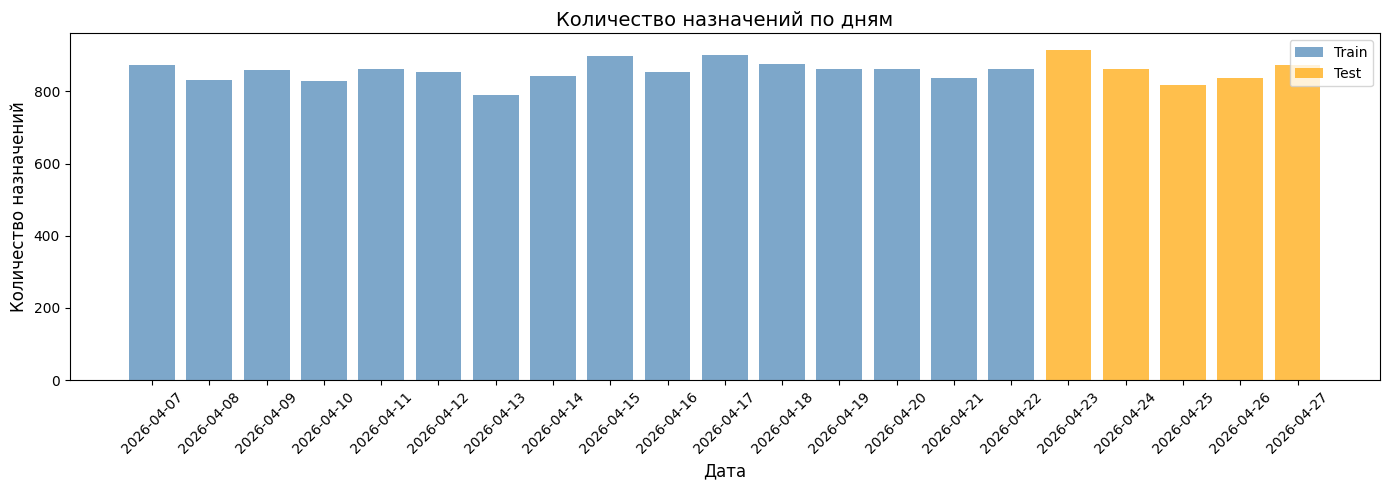

In [27]:
print("РАСПРЕДЕЛЕНИЕ ПО ДАТАМ")

# Конвертация дат
train['assignment_date'] = pd.to_datetime(train['assignment_date'])
test['assignment_date'] = pd.to_datetime(test['assignment_date'])

print(f"Train: {train['assignment_date'].min()} - {train['assignment_date'].max()} ({train['assignment_date'].nunique()} дней)")
print(f"Test:  {test['assignment_date'].min()} - {test['assignment_date'].max()} ({test['assignment_date'].nunique()} дней)")
print()

# Количество записей по дням (train)
daily_counts = train.groupby(train['assignment_date'].dt.date).size().sort_index()

print("Топ-5 дней по количеству назначений (train):")
print(daily_counts.sort_values(ascending=False).head(5))
print()

print("Топ-5 дней по количеству назначений (test):")
test_daily_counts = test.groupby(test['assignment_date'].dt.date).size().sort_index()
print(test_daily_counts.sort_values(ascending=False).head(5))
print()

# Проверка, что тест позже train
print("Сравнение дат (train vs test)")
print(f"Train: {train['assignment_date'].min()} - {train['assignment_date'].max()}")
print(f"Test:  {test['assignment_date'].min()} - {test['assignment_date'].max()}")

if test['assignment_date'].min() > train['assignment_date'].max():
    print("Test позже train. Используем временную валидацию")
else:
    print("Test пересекается с train по времени")
print()

# Визуализация (опционально)
plt.figure(figsize=(14, 5))
plt.bar(daily_counts.index.astype(str), daily_counts.values, color='steelblue', alpha=0.7, label='Train')
plt.bar(test_daily_counts.index.astype(str), test_daily_counts.values, color='orange', alpha=0.7, label='Test')
plt.title('Количество назначений по дням', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество назначений', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#### 2.3. Анализ пропусков

In [28]:
print("АНАЛИЗ ПРОПУСКОВ в train.csv")

missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f"Всего колонок с пропусками: {len(missing)} из {len(train.columns)}")
print()

if len(missing) > 0:
    print("Топ-10 колонок с пропусками:")
    for col in missing.head(10).index:
        cnt = missing[col]
        pct = cnt/len(train) * 100
        print(f"  {col:<35}:{cnt:>5} пропусков ({pct:>5.1f}%)")
else:
    print("Пропусков нет")
print()

АНАЛИЗ ПРОПУСКОВ в train.csv
Всего колонок с пропусками: 97 из 119

Топ-10 колонок с пропусками:
  seller_response_rate_30d           :  708 пропусков (  5.2%)
  leadgen_prev_positive_90d          :  452 пропусков (  3.3%)
  item_favorites_3d                  :  451 пропусков (  3.3%)
  query_refinements_30d              :  446 пропусков (  3.3%)
  detail_expands_3d                  :  445 пропусков (  3.2%)
  user_contacts_3d                   :  436 пропусков (  3.2%)
  leadgen_prev_assigned_7d           :  435 пропусков (  3.2%)
  call_clicks_14d                    :  434 пропусков (  3.2%)
  call_clicks_30d                    :  433 пропусков (  3.2%)
  user_contacts_14d                  :  433 пропусков (  3.2%)



#### 2.4. Описательная статистика для числовых и категориальных переменных

In [29]:
print("ЧИСЛОВЫЕ ПРИЗНАКИ в train.csv")

# Исключение target из числовых переменных
numeric_cols_no_target = [col for col in numeric_cols if col != TARGET]

desc = train[numeric_cols_no_target].describe().T
desc['missing'] = train[numeric_cols_no_target].isnull().sum()
desc['missing_pct'] = (desc['missing'] / len(train) * 100).round(1)

print("Топ-10 по среднему значению:")
print(desc.sort_values('mean', ascending=False).head(10)[['mean', 'std', 'min', 'max', 'missing_pct']])
print()

print("Топ-10 по пропускам:")
print(desc.sort_values('missing_pct', ascending=False).head(10)[['mean', 'std', 'min', 'max', 'missing_pct']])
print()

ЧИСЛОВЫЕ ПРИЗНАКИ в train.csv
Топ-10 по среднему значению:
                               mean         std   min     max  missing_pct
user_age_days            415.899664  420.696887   1.0  4088.0          0.0
item_views_90d            92.636869   52.931369  11.0   451.0          2.9
search_views_90d          56.158422   32.487257   5.0   279.0          3.0
photo_swipes_90d          46.844434   26.191584   3.0   223.0          3.0
item_views_30d            30.805566   18.101935   0.0   159.0          2.9
search_views_30d          18.675333   11.285385   0.0    99.0          3.1
similar_item_clicks_90d   18.423641   10.911632   0.0    94.0          2.9
seller_inventory_count    17.466409   17.781823   1.0   184.0          0.0
photo_swipes_30d          15.481554    9.485460   0.0    87.0          3.0
assignment_hour           14.477654    2.800490   9.0    21.0          0.0

Топ-10 по пропускам:
                               mean       std       min        max  \
seller_response_rate_30d

In [30]:
print("КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ в train.csv")

# Колонки, которые не используем как признаки модели
ID_COLUMNS = {"lead_id", "user_id"}
TIME_COLUMNS = {"assignment_ts", "assignment_date"}
NON_FEATURE_COLUMNS = ID_COLUMNS | TIME_COLUMNS | {TARGET, "split"}

ignore_cols = list(ID_COLUMNS | TIME_COLUMNS)
cat_cols_ignore = [col for col in cat_cols_all if col in ignore_cols]

# Категориальные колонки, которые используем как признаки
cat_cols_features = [col for col in cat_cols_all if col not in ignore_cols]
print(f"Не используем как признаки: {cat_cols_ignore}")
print()
print("Используем как признаки:")
for col in cat_cols_features:
    freq = train[col].value_counts().head(3)
    freq_dict = {k: int(v) for k, v in freq.items()}
    print(f"  * {col}: {train[col].nunique()} уникальных значений \n{freq_dict}")
print()

КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ в train.csv
Не используем как признаки: ['lead_id', 'user_id', 'assignment_ts', 'assignment_date']

Используем как признаки:
  * lead_source: 3 уникальных значений 
{'Model': 5688, 'CRM': 4839, 'Perf': 3167}
  * call_center: 2 уникальных значений 
{'external': 7882, 'voxys': 5812}
  * region: 5 уникальных значений 
{'east': 2796, 'west': 2770, 'central': 2725}
  * car_segment: 4 уникальных значений 
{'standard': 5780, 'budget': 4713, 'premium': 1909}
  * lead_channel: 4 уникальных значений 
{'web': 3518, 'app': 3408, 'retargeting': 3385}
  * user_tenure_bucket: 3 уникальных значений 
{'warm': 6175, 'new': 4121, 'loyal': 3398}
  * price_bucket: 3 уникальных значений 
{'mid': 7076, 'low': 4170, 'high': 2448}



In [31]:
print("ДОБАВЛЕНИЕ ФЛАГОВ ПРОПУСКОВ")

# 1. Нахождение колонки с пропусками в исходных данных
cols_with_missing = train.columns[
    train.isnull().any()
].tolist()

# Исключtybt ID, время и target
ID_COLUMNS = {"lead_id", "user_id"}
TIME_COLUMNS = {"assignment_ts", "assignment_date"}
cols_with_missing = [
    col for col in cols_with_missing
    if col not in ID_COLUMNS | TIME_COLUMNS | {TARGET}
]

print(f"Колонок с пропусками: {len(cols_with_missing)}")
print(f"Примеры: {cols_with_missing[:5]}...")
print()

# 2. Добавление флаги в train и test
for col in cols_with_missing:
    train[f'{col}_is_missing'] = train[col].isnull().astype(int)
    test[f'{col}_is_missing'] = test[col].isnull().astype(int)

print(f"Добавлено {len(cols_with_missing)} флагов пропусков")
print(f"В train: {train.shape[1]} колонок")
print(f"В test:  {test.shape[1]} колонок")

ДОБАВЛЕНИЕ ФЛАГОВ ПРОПУСКОВ
Колонок с пропусками: 97
Примеры: ['seller_response_rate_30d', 'item_views_1d', 'item_views_3d', 'item_views_7d', 'item_views_14d']...

Добавлено 97 флагов пропусков
В train: 216 колонок
В test:  215 колонок


### 3. Построение признаков из events.csv

In [32]:
print("ПОСТРОЕНИЕ НОВЫХ ПРИЗНАКОВ ИЗ EVENTS.CSV")

# 1. Конвертация времени
events['event_ts'] = pd.to_datetime(events['event_ts'])
train['assignment_ts'] = pd.to_datetime(train['assignment_ts'])
test['assignment_ts'] = pd.to_datetime(test['assignment_ts'])

# 2. Фильтрование событий до назначения (защита от data leakage)
events_train = events.merge(
    train[['lead_id', 'assignment_ts']],
    on='lead_id',
    how='inner'
)

events_before = events_train[events_train['event_ts'] < events_train['assignment_ts']]

print(f"Событий до назначения: {len(events_before)} из {len(events_train)}")
print(f"Это {len(events_before)/len(events_train)*100:.1f}% от всех событий")
print()

# 3. Агрегация событий по каждому обращению

# 3.1. Общее количество событий
event_features = events_before.groupby('lead_id').agg(
    total_events=('event_ts', 'count')
).reset_index()

# 3.2. Количество уникальных типов событий
event_types_count = events_before.groupby('lead_id')['event_type'].nunique().reset_index()
event_types_count.columns = ['lead_id', 'unique_event_types']
event_features = event_features.merge(event_types_count, on='lead_id', how='left')

# 3.3. Разброс событий во времени (Сколько дней прошло между первым и последним событием)
def days_between(x):
    return (x.max() - x.min()).days if len(x) > 1 else 0

event_days = events_before.groupby('lead_id')['event_ts'].agg(days_between).reset_index()
event_days.columns = ['lead_id', 'event_span_days']
event_features = event_features.merge(event_days, on='lead_id', how='left')

# 3.4. Количество событий каждого типа (также добавление префикса 'nw_' к новым признакам для понимания)
event_pivot = pd.crosstab(
    events_before['lead_id'],
    events_before['event_type']
).reset_index().rename_axis(None, axis=1)

event_pivot.columns = ['lead_id'] + [f'nw_{col}' for col in event_pivot.columns if col != 'lead_id']

# Объединение всех признаков
event_features = event_features.merge(event_pivot, on='lead_id', how='left').fillna(0)

print("СПИСОК НОВЫХ ПРИЗНАКОВ ИЗ EVENTS:")

# Все колонки в event_features (кроме lead_id)
new_feature_cols = [col for col in event_features.columns if col != 'lead_id']

for i, col in enumerate(new_feature_cols, 1):
    sample_val = event_features[col].iloc[0]
    print(f"  {i:2d}. {col:<25} | пример: {sample_val}") # Это пример значения признака

print()
print(f"Итого: {len(new_feature_cols)} новых признаков")
print()

# 4. Присоединение к train и test
train_with_events = train.merge(event_features, on='lead_id', how='left').fillna(0)
test_with_events = test.merge(event_features, on='lead_id', how='left').fillna(0)

print(f"train с новыми признаками: {train_with_events.shape}")
print(f"test с новыми признаками:  {test_with_events.shape}")
print()

# Проверка: все ли lead_id из train есть в event_features
missing_in_train = set(train['lead_id']) - set(event_features['lead_id'])
if missing_in_train:
    print(f" !{len(missing_in_train)} обращений без событий!")
else:
    print("Все обращения имеют события")
print()

print("\nСТАТИСТИКА НОВЫХ ПРИЗНАКОВ:")
print(event_features[new_feature_cols].describe().round(2))

ПОСТРОЕНИЕ НОВЫХ ПРИЗНАКОВ ИЗ EVENTS.CSV
Событий до назначения: 181297 из 197421
Это 91.8% от всех событий

СПИСОК НОВЫХ ПРИЗНАКОВ ИЗ EVENTS:
   1. total_events              | пример: 10
   2. unique_event_types        | пример: 4
   3. event_span_days           | пример: 22
   4. nw_call_click             | пример: 1
   5. nw_chat_open              | пример: 1
   6. nw_favorite               | пример: 0
   7. nw_item_view              | пример: 6
   8. nw_search                 | пример: 2

Итого: 8 новых признаков

train с новыми признаками: (13694, 224)
test с новыми признаками:  (4306, 223)

 !20 обращений без событий!


СТАТИСТИКА НОВЫХ ПРИЗНАКОВ:
       total_events  unique_event_types  event_span_days  nw_call_click  \
count      13674.00            13674.00         13674.00       13674.00   
mean          13.26                3.91            24.50           1.07   
std            6.29                0.97             4.73           1.11   
min            1.00                1.00

### 4. Валидация и обучение модели

#### 4.1. Определение признаков для обучения модели

In [33]:
# Список признаков (все колонки, кроме ID, time и target)
feature_columns = [
    col for col in train_with_events.columns
    if col not in NON_FEATURE_COLUMNS
    and col in test_with_events.columns
]

print("СПИСОК ВСЕХ ПРИЗНАКОВ")

print(f"Всего признаков: {len(feature_columns)}")
print()
# Выводим все признаки (было 127 после добавления признаков из events, убираем 4 категориальных признака (ID, Time) и таргет= 122 признака)

СПИСОК ВСЕХ ПРИЗНАКОВ
Всего признаков: 219



#### 4.2. Валидация

Так как тестовая выборка находится позже train по времени, валидиция на последних датах train.

In [34]:
print("ВАЛИДАЦИЯ")
"""Делит train по времени: ранние даты в обучение, поздние даты в валидацию."""
# Берем все уникальные даты
dates = pd.to_datetime(train_with_events['assignment_date']).dt.date
unique_dates = sorted(dates.unique())

# Отрезаем 30% последних дат для валидации
cutoff_idx = int(len(unique_dates) * 0.7)
cutoff_date = unique_dates[cutoff_idx]

# Делим
train_part = train_with_events[dates < cutoff_date].copy()
valid_part = train_with_events[dates >= cutoff_date].copy()

print(f"train_part: {train_part.shape[0]} строк (даты до {cutoff_date})")
print(f"valid_part: {valid_part.shape[0]} строк (даты с {cutoff_date})")

ВАЛИДАЦИЯ
train_part: 9397 строк (даты до 2026-04-18)
valid_part: 4297 строк (даты с 2026-04-18)


In [35]:
print("ПРЕОБРАЗОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")

# Находим категориальные признаки с типом object для дальнейшего обучения модели
cat_columns = train_part.select_dtypes(include=['object']).columns.tolist()
print(f"Найдено категориальных признаков: {len(cat_columns)}")
print(f"{cat_columns}")

# Преобразуем в тип 'category' во всех выборках
for col in cat_columns:
    train_part[col] = train_part[col].astype('category')
    valid_part[col] = valid_part[col].astype('category')
    test_with_events[col] = test_with_events[col].astype('category')
    train_with_events[col] = train_with_events[col].astype('category')

# Проверка
cat_columns_checked = train_part.select_dtypes(include=['category']).columns.tolist()
print(f"Преобразовано в 'category': {len(cat_columns_checked)} колонок")

ПРЕОБРАЗОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
Найдено категориальных признаков: 9
['lead_id', 'user_id', 'lead_source', 'call_center', 'region', 'car_segment', 'lead_channel', 'user_tenure_bucket', 'price_bucket']
Преобразовано в 'category': 9 колонок


#### 4.3. Обучение модели

Используется **LightGBM** с early stopping.

Сначала обучается базовая модель с фиксированными гиперпараметрами, затем применяется **ансамбль из 3 моделей** с разными seed для повышения стабильности и качества прогнозов.

- Категориальные признаки: преобразованы в тип `category`; LightGBM обрабатывает их автоматически через `categorical_feature='auto'`
- Дисбаланс классов: модель оптимизирует ROC-AUC (`metric='auc'`), которая устойчива к дисбалансу
- Валидация: early stopping (50 раундов без улучшения AUC на валидации)
- Финальная метрика: **Average Precision (AP)** — соответствует условиям задачи
- Ансамбль: 3 модели с random_state = 42, 123, 456; предсказания усредняются

In [36]:
print("ОБУЧЕНИЕ LIGHTGBM (baseline)")

params_base = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'max_depth': -1,
    'learning_rate': 0.05,
    'n_estimators': 500,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.0,
    'reg_lambda': 1.0,
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1,
}

model_base = lgb.LGBMClassifier(**params_base)
model_base.fit(
    train_part[feature_columns],
    train_part[TARGET],
    eval_set=[(valid_part[feature_columns], valid_part[TARGET])],
    eval_metric='auc',
    categorical_feature='auto',
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

valid_scores_base = model_base.predict_proba(valid_part[feature_columns])[:, 1]
valid_ap_base = average_precision_score(valid_part[TARGET], valid_scores_base)

print(f"LightGBM (baseline) AP: {valid_ap_base:.5f}")
print(f"Улучшение от baseline: {((valid_ap_base - 0.48506) / 0.48506 * 100):.1f}%")
print()

ОБУЧЕНИЕ LIGHTGBM (baseline)
LightGBM (baseline) AP: 0.55024
Улучшение от baseline: 13.4%



In [37]:
print("АНСАМБЛЬ МОДЕЛЕЙ (3 seed)")

import numpy as np

# Определение базовых параметров модели
params_final = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'max_depth': -1,
    'learning_rate': 0.05,
    'n_estimators': 500,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.0,
    'reg_lambda': 1.0,
    'verbose': -1,
    'n_jobs': -1,
}

# Обучение трех моделей с разными seed
seeds = [42, 123, 456]
test_predictions = []

for seed in seeds:
    print(f"Обучаем модель с seed = {seed}...")
    params = params_final.copy()
    params['random_state'] = seed
    
    model = lgb.LGBMClassifier(**params)
    model.fit(
        train_with_events[feature_columns],
        train_with_events[TARGET],
        categorical_feature='auto'
    )
    pred = model.predict_proba(test_with_events[feature_columns])[:, 1]
    test_predictions.append(pred)
    print(f"Модель {seed} обучена")

# Усреднение предсказания
test_scores_ensemble = np.mean(test_predictions, axis=0)

АНСАМБЛЬ МОДЕЛЕЙ (3 seed)
Обучаем модель с seed = 42...
Модель 42 обучена
Обучаем модель с seed = 123...
Модель 123 обучена
Обучаем модель с seed = 456...
Модель 456 обучена


#### 4.4. Анализ важности признаков

АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
ТОП-20 ВАЖНЫХ ПРИЗНАКОВ:
                 feature  importance
   seller_page_views_30d         379
   seller_page_views_14d         307
           user_age_days         243
    seller_page_views_7d         229
        search_views_90d         219
seller_response_rate_30d         207
          mileage_km_log         205
           car_age_years         198
        photo_swipes_90d         177
          item_views_90d         156
          item_price_log         144
  seller_inventory_count         142
      detail_expands_90d         139
   query_refinements_90d         136
          item_views_14d         126
 similar_item_clicks_90d         126
 similar_item_clicks_30d         122
      item_favorites_90d         117
       user_contacts_90d         117
             lead_source         114

ПРИЗНАКИ ИЗ EVENTS В ТОП-30:
           feature  importance
   event_span_days         112
      total_events         103
       nw_favorite         103
         nw_search

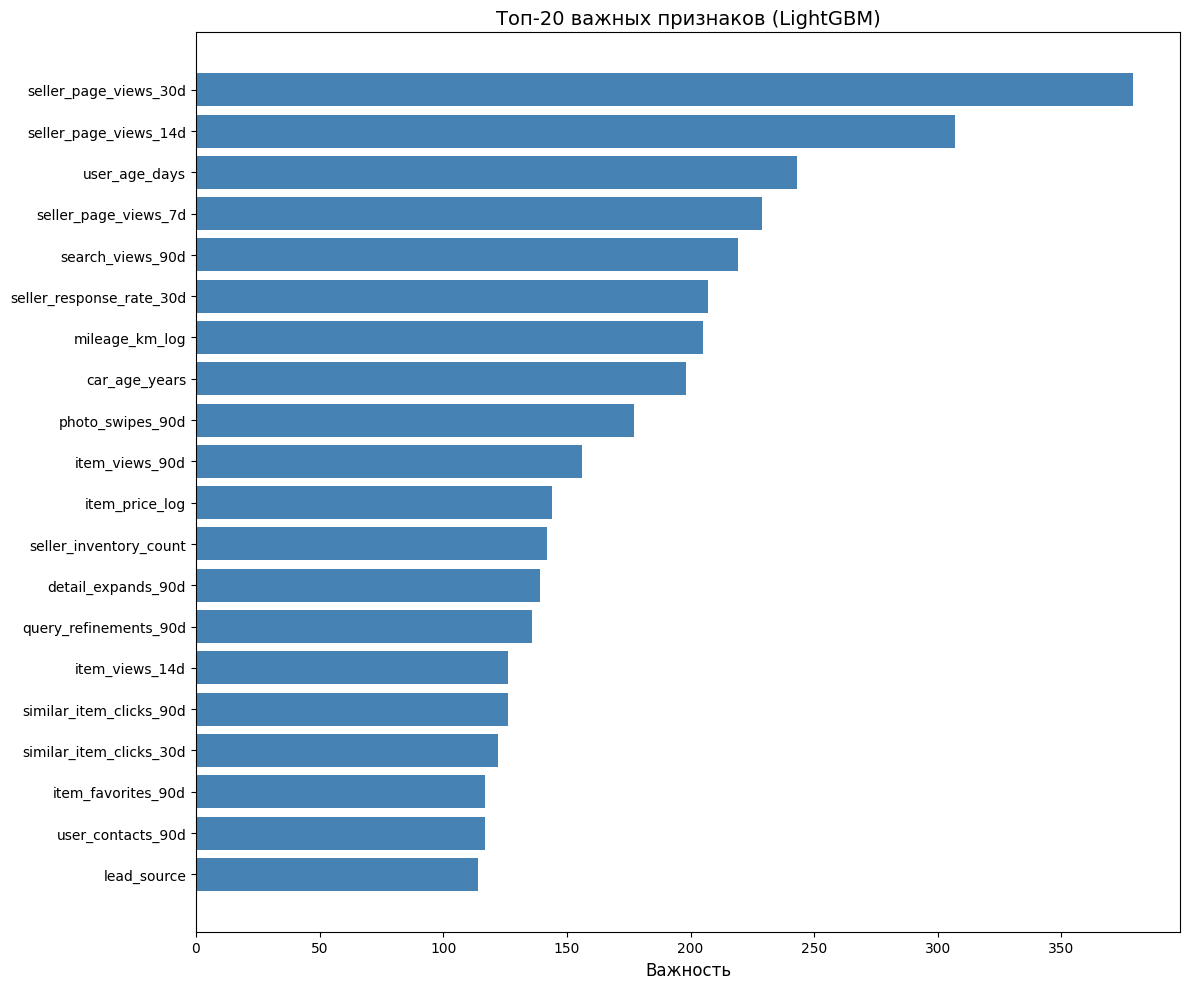

In [38]:
print("АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")

import matplotlib.pyplot as plt

# Используем базовую модель
importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model_base.feature_importances_
}).sort_values('importance', ascending=False)

print("ТОП-20 ВАЖНЫХ ПРИЗНАКОВ:")
print(importance.head(20).to_string(index=False))
print()

# Проверка: признаки из events в топ-30
print("ПРИЗНАКИ ИЗ EVENTS В ТОП-30:")
events_features = [col for col in feature_columns 
                   if col.startswith('nw_') or col in ['total_events', 'unique_event_types', 'event_span_days']]
events_importance = importance[importance['feature'].isin(events_features)]
print(events_importance.to_string(index=False))
print()

# Визуализация
plt.figure(figsize=(12, 10))
plt.barh(importance['feature'][:20], importance['importance'][:20], color='steelblue')
plt.title('Топ-20 важных признаков (LightGBM)', fontsize=14)
plt.xlabel('Важность', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### 5. Формирование submission 

In [44]:
# Создание сабмишена 
submission_ensemble = pd.DataFrame({
    "lead_id": test_with_events["lead_id"].astype(str),
    "score": test_scores_ensemble
})
submission_ensemble.to_csv("submission_ensemble_70.csv", index=False)

print("submission_ensemble_70.csv сохранен")
print(f"Количество строк: {len(submission_ensemble)}")
print("\nПервые 5 строк:")
print(submission_ensemble.head())

# Проверка
assert list(submission_ensemble.columns) == ["lead_id", "score"]
assert len(submission_ensemble) == len(test_with_events)
assert submission_ensemble["lead_id"].is_unique
print("\nВсе проверки пройдены. Файл готов к отправке.")

submission_ensemble_70.csv сохранен
Количество строк: 4306

Первые 5 строк:
                 lead_id     score
0  lead_97e409eb8f8c8246  0.465384
1  lead_55310edb4489f9e9  0.112781
2  lead_e7f653a2c6a7eee8  0.696760
3  lead_22f8e1cfc487ac20  0.032950
4  lead_48b638b839abfac3  0.066028

Все проверки пройдены. Файл готов к отправке.


In [40]:
print("DAILY AP НА ВАЛИДАЦИИ (опционально)")

# Получение предсказания на валидации от ансамбля
valid_predictions = []

for seed in seeds:
    params = params_final.copy()
    params['random_state'] = seed
    model = lgb.LGBMClassifier(**params)
    model.fit(
        train_part[feature_columns],
        train_part[TARGET],
        categorical_feature='auto'
    )
    pred_val = model.predict_proba(valid_part[feature_columns])[:, 1]
    valid_predictions.append(pred_val)

valid_scores_ensemble = np.mean(valid_predictions, axis=0)
valid_ap_ensemble = average_precision_score(valid_part[TARGET], valid_scores_ensemble)

print(f"Обычный AP на валидации: {valid_ap_ensemble:.5f}")

# Расчет Daily AP на валидации
valid_df = valid_part.copy()
valid_df['score'] = valid_scores_ensemble

daily_aps = []
for date in valid_df['assignment_date'].unique():
    day_data = valid_df[valid_df['assignment_date'] == date]
    ap_day = average_precision_score(day_data[TARGET], day_data['score'])
    daily_aps.append(ap_day)

daily_ap = np.mean(daily_aps)
print(f"Daily AP на валидации:   {daily_ap:.5f}")
print(f"Разница:                 {valid_ap_ensemble - daily_ap:.5f}")

print("ИТОГОВОЕ СРАВНЕНИЕ")

baseline_ap = 0.48506

print(f"Baseline (Logistic Regression): {baseline_ap:.5f}")
print(f"LightGBM (базовый):             {valid_ap_base:.5f}")
print(f"LightGBM (ансамбль 3 seed):     {valid_ap_ensemble:.5f}")

improvement_base = ((valid_ap_base - baseline_ap) / baseline_ap * 100)
improvement_ensemble = ((valid_ap_ensemble - baseline_ap) / baseline_ap * 100)

print(f"\nУлучшение базового LightGBM:  {improvement_base:.1f}%")
print(f"Улучшение ансамбля:           {improvement_ensemble:.1f}%")

DAILY AP НА ВАЛИДАЦИИ (опционально)
Обычный AP на валидации: 0.55451
Daily AP на валидации:   0.55976
Разница:                 -0.00525
ИТОГОВОЕ СРАВНЕНИЕ
Baseline (Logistic Regression): 0.48506
LightGBM (базовый):             0.55024
LightGBM (ансамбль 3 seed):     0.55451

Улучшение базового LightGBM:  13.4%
Улучшение ансамбля:           14.3%
